# Classifying the 100K H&E dataset - 1

Method: Following the Pytorch classifier tutorial* with the 100K H&E dataset

Author: Marissa Esteban

Date: 04/22/2026

Data: Kather, Jakob Nikolas, Halama, Niels, & Marx, Alexander. (2018). 100,000 histological images of human colorectal cancer and healthy tissue (v0.1) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.1214456

Pytorch Tutorial* : https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html


Outcomes: 


In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from torch import nn
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor, Lambda
from torch.utils.data import DataLoader

In [6]:
# importing the data

batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(
    # root="D:\\me2982@cumc.columbia.edu\\bianca\\NCT-CRC-HE-100K",   # path to the unzipped folder
    root = "/Volumes/PortableSSD/me2982@cumc.columbia.edu/bianca/NCT-CRC-HE-100K",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    # root="D:\\me2982@cumc.columbia.edu\\bianca\\CRC-VAL-HE-7K",
    root = "/Volumes/PortableSSD/me2982@cumc.columbia.edu/bianca/CRC-VAL-HE-7K",
    transform=transform
)


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=True, num_workers=0)

classes = train_dataset.classes

# Check it loaded correctly
print(train_dataset.classes)   # ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
print(len(train_dataset))      # 100000

['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
100000


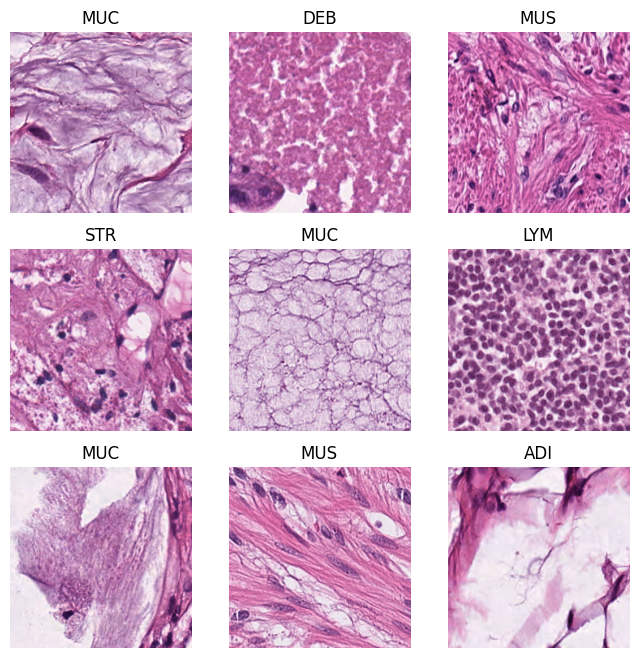

In [7]:
# visualizing some of the images

labels_map = {
    0: "ADI",
    1: "BACK",
    2: "DEB",
    3: "LYM",
    4: "MUC",
    5: "MUS",
    6: "NORM",
    7: "STR",
    8: "TUM",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")

    # undo the normalization
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    img = img * std[:, None, None] + mean[:, None, None]  # [3, 224, 224]

    plt.imshow(img.permute(1, 2, 0))  # reorder from [C, H, W] → [H, W, C]
plt.show()


In [17]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


### Defining the NN and training


In [28]:
# assuming the input is 224 x 224

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 53 * 53, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net().to(device)
print(net)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=44944, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [29]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [30]:
# training the network
train_losses = []
val_losses = []
val_accuracy = []

for epoch in range(10):  # loop over the dataset multiple times

    running_loss = 0.0
    epoch_loss = 0.0
    net.train()
    for i, data in enumerate(train_loader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()   
        epoch_loss += loss.item()     

        if i % 200 == 199:    # print every 200 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 200:.3f}')
            running_loss = 0.0
        

    train_losses.append(epoch_loss / len(train_loader))
    
    # --- validation ---
    net.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_losses.append(val_loss / len(val_loader))
    val_accuracy.append(correct / total)
    print(f'Epoch {epoch + 1} complete | val loss: {val_losses[-1]:.3f}, val accuracy: {val_accuracy[-1]:.3f}')

print('Finished Training')

[1,   200] loss: 2.042
[1,   400] loss: 1.330
[1,   600] loss: 1.137
[1,   800] loss: 1.056
[1,  1000] loss: 0.989
[1,  1200] loss: 0.961
[1,  1400] loss: 0.919
Epoch 1 complete | val loss: 0.954, val accuracy: 0.675
[2,   200] loss: 0.853
[2,   400] loss: 0.798
[2,   600] loss: 0.783
[2,   800] loss: 0.767
[2,  1000] loss: 0.753
[2,  1200] loss: 0.722
[2,  1400] loss: 0.709
Epoch 2 complete | val loss: 0.743, val accuracy: 0.731
[3,   200] loss: 0.668
[3,   400] loss: 0.618
[3,   600] loss: 0.614
[3,   800] loss: 0.595
[3,  1000] loss: 0.594
[3,  1200] loss: 0.567
[3,  1400] loss: 0.586
Epoch 3 complete | val loss: 0.708, val accuracy: 0.799
[4,   200] loss: 0.522
[4,   400] loss: 0.483
[4,   600] loss: 0.481
[4,   800] loss: 0.480
[4,  1000] loss: 0.492
[4,  1200] loss: 0.466
[4,  1400] loss: 0.461
Epoch 4 complete | val loss: 0.802, val accuracy: 0.781
[5,   200] loss: 0.389
[5,   400] loss: 0.381
[5,   600] loss: 0.403
[5,   800] loss: 0.383
[5,  1000] loss: 0.363
[5,  1200] loss: 

In [32]:
import json

# save training and validation losses and accuracy to a json file
with open("losses.json", "w") as f:
    json.dump({
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracy": val_accuracy
    }, f)

# saving our model
# PATH = 'D:\\me2982@cumc.columbia.edu\\bianca\\models\\first_nn.pth'
PATH = "/Volumes/PortableSSD/me2982@cumc.columbia.edu/bianca/models/first_nn.pth"
torch.save(net.state_dict(), PATH)

In [33]:
train_losses

[1.1720773046472786,
 0.7630179686303789,
 0.6017915591626158,
 0.47951309335247033,
 0.37988336950597745,
 0.2848673773523103,
 0.2027564822140216,
 0.13720257033642216,
 0.08436371844145096,
 0.051681331152385976]

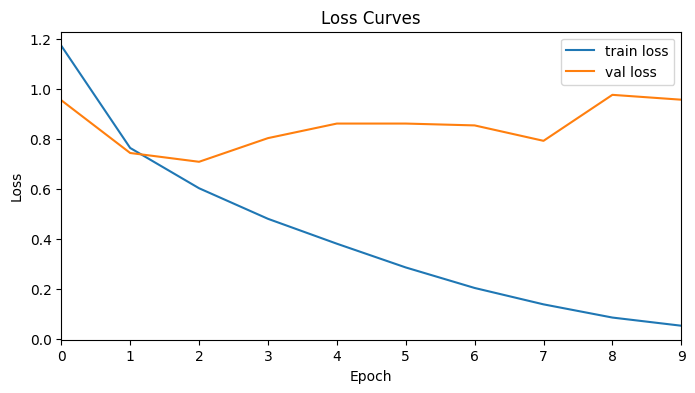

In [34]:
# RUN THIS AGAIN. HAD TO FIX THE TRAINING LOSSES

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')
plt.xlim(0, 9)
plt.show()

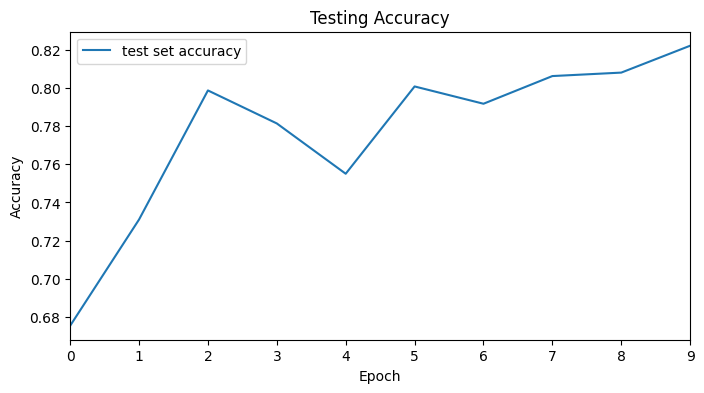

In [35]:
plt.figure(figsize=(8, 4))
plt.plot(val_accuracy, label='test set accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Testing Accuracy')
plt.xlim(0, 9)
plt.show()

### Testing with our held out testset

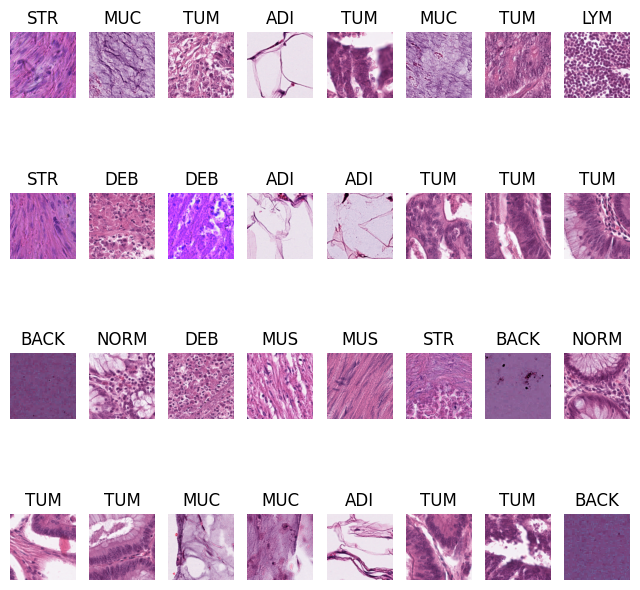

In [36]:
dataiter = iter(val_loader)
images, labels = next(dataiter)

figure = plt.figure(figsize=(8, 8))
rows, cols = 4, 8
for i in range(1, cols * rows + 1):

    img = images[i-1]
    label = labels[i-1]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label.item()])
    plt.axis("off")

    # undo the normalization
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    img = img * std[:, None, None] + mean[:, None, None]  # [3, 224, 224]

    plt.imshow(img.permute(1, 2, 0))  # reorder from [C, H, W] → [H, W, C]
plt.show()

In [39]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in val_loader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 7000 validation images: {100 * correct // total} %')

Accuracy of the network on the 7000 validation images: 82 %


In [40]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in val_loader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: ADI   is 85.4 %
Accuracy for class: BACK  is 93.2 %
Accuracy for class: DEB   is 58.4 %
Accuracy for class: LYM   is 97.8 %
Accuracy for class: MUC   is 93.3 %
Accuracy for class: MUS   is 60.5 %
Accuracy for class: NORM  is 78.1 %
Accuracy for class: STR   is 61.5 %
Accuracy for class: TUM   is 80.4 %


## Visualizing embeddings using uMAP

In [41]:
print(list(net.children()))

[Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1)), MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False), Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1)), Linear(in_features=44944, out_features=120, bias=True), Linear(in_features=120, out_features=84, bias=True), Linear(in_features=84, out_features=10, bias=True)]


In [ ]:
class cnnEmbedding(nn.Module):
